# Visualisation des performances

L'objectif de ce notebook est de générer des graphiques de comparaison des performances des modèles et des joueurs mixtes après l'entraînement supervisé, après l'entraînement PPO et en validation finale.

In [1]:
#Librairies
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Chargement des données
df_stats = pd.read_csv("../models/metrics/statistiques-modeles.csv")
df_stats

,Modèle,Type,Supervisé,Pré-entrainement tête valeur,Entraînement PPO,Architecture,Algorithme complémentaire,Classe du joueur,Win-rate vs LA1,Win-rate vs LA2,Win-rate vs LA3,Temps d'inférence
0,Musashi1,CNN,X,,,v4,,CNNPlayer_v4,79,11,4,
1,Musashi2,CNN,X,X,,v4,,CNNPlayer_v4,80,18,3,
2,Musash3,CNN,X,X,X,v4,,CNNPlayer_v4,88,40,20,
3,Kamae1,CNN,X,,,v6,,CNNPlayer_v6,85,33,9,
4,Kamae2,CNN,X,,,v6,,CNNPlayer_v6,93,37,11,
5,Kamae3,CNN,X,X,,v6,,CNNPlayer_v6,91,39,16,
6,Kamae4,CNN,X,X,X,v6,,CNNPlayer_v6,95,47,17,
7,Kamae5,CNN,X,X,X,v6,,CNNPlayer_v6,93,51,27,
8,Tairanauchu1,Dense,X,,,v7,,DensePlayer_v7,91,26,5,
9,Tairanauchu2,Dense,X,X,,v7,,DensePlayer_v7,94,26,6,


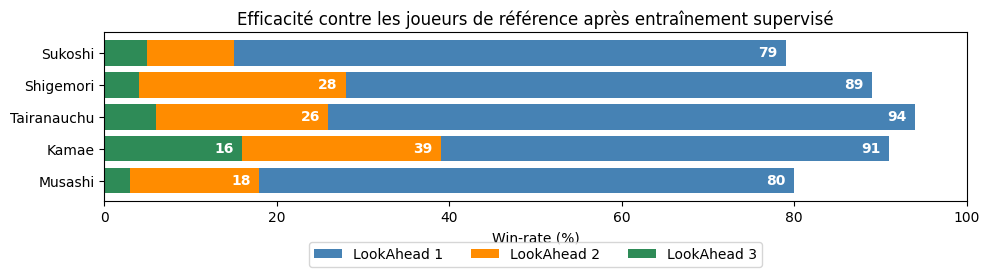

In [3]:
df_data = df_stats.iloc[[1, 5, 9, 12, 15]]
modeles = df_data['Modèle'].str.rstrip('0123456789').tolist()

la1 = df_data['Win-rate vs LA1'].tolist()
la2 = df_data['Win-rate vs LA2'].tolist()
la3 = df_data['Win-rate vs LA3'].tolist()

fig, ax = plt.subplots(figsize=(10, 3))

ax.barh(modeles, la1, label='LookAhead 1', color='steelblue')
ax.barh(modeles, la2, label='LookAhead 2', color='darkorange')
ax.barh(modeles, la3, label='LookAhead 3', color='seagreen')

pad = 1
min_width = 12 

for i, (v1, v2, v3) in enumerate(zip(la1, la2, la3)):
    if v1 - v2 >= min_width:
        ax.text(v1 - pad, i, str(v1), ha='right', va='center', color='white', fontweight='bold')
    if v2 - v3 >= min_width:
        ax.text(v2 - pad, i, str(v2), ha='right', va='center', color='white', fontweight='bold')
    if v3 >= min_width:
        ax.text(v3 - pad, i, str(v3), ha='right', va='center', color='white', fontweight='bold')

ax.set_xlim(0, 100)
ax.set_xlabel('Win-rate (%)')
ax.set_title('Efficacité contre les joueurs de référence après entraînement supervisé')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncols=3)
plt.tight_layout()

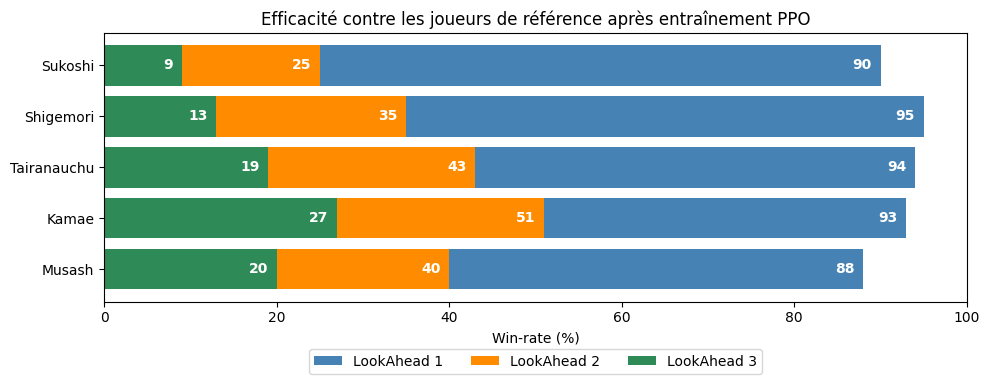

In [4]:
df_data = df_stats.iloc[[2, 7, 10, 13, 16]]
modeles = df_data['Modèle'].str.rstrip('0123456789').tolist()

la1 = df_data['Win-rate vs LA1'].tolist()
la2 = df_data['Win-rate vs LA2'].tolist()
la3 = df_data['Win-rate vs LA3'].tolist()

fig, ax = plt.subplots(figsize=(10, 4))

ax.barh(modeles, la1, label='LookAhead 1', color='steelblue')
ax.barh(modeles, la2, label='LookAhead 2', color='darkorange')
ax.barh(modeles, la3, label='LookAhead 3', color='seagreen')

pad = 1
for i, (v1, v2, v3) in enumerate(zip(la1, la2, la3)):
    ax.text(v1 - pad, i, str(v1), ha='right', va='center', color='white', fontweight='bold')
    ax.text(v2 - pad, i, str(v2), ha='right', va='center', color='white', fontweight='bold')
    ax.text(v3 - pad, i, str(v3), ha='right', va='center', color='white', fontweight='bold')

ax.set_xlim(0, 100)
ax.set_xlabel('Win-rate (%)')
ax.set_title('Efficacité contre les joueurs de référence après entraînement PPO')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols=3)
plt.tight_layout()

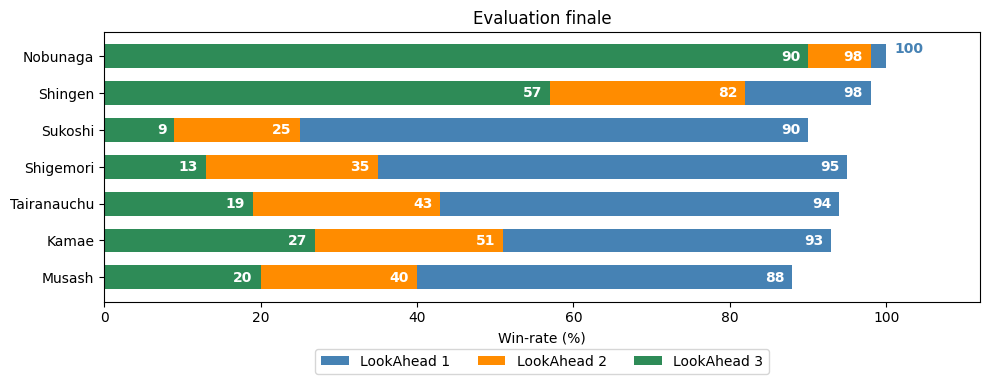

In [ ]:
df_data = df_stats.iloc[[2, 7, 10, 13, 16, 17, 18]]
modeles = df_data['Modèle'].str.rstrip('0123456789').tolist()

la1 = df_data['Win-rate vs LA1'].tolist()
la2 = df_data['Win-rate vs LA2'].tolist()
la3 = df_data['Win-rate vs LA3'].tolist()

fig, ax = plt.subplots(figsize=(10, 4))

h = 0.65
ax.barh(modeles, la1, height=h, label='LookAhead 1', color='steelblue')
ax.barh(modeles, la2, height=h, label='LookAhead 2', color='darkorange')
ax.barh(modeles, la3, height=h, label='LookAhead 3', color='seagreen')

pad = 1
min_width = 7

for i, (v1, v2, v3) in enumerate(zip(la1, la2, la3)):
    inside1 = v1 - v2 >= min_width
    inside2 = v2 - v3 >= min_width
    inside3 = v3      >= min_width

    if inside1:
        ax.text(v1 - pad, i, str(v1), ha='right', va='center', color='white',      fontweight='bold')
    else:
        ax.text(v1 + pad, i + 0.2, str(v1), ha='left', va='center', color='steelblue',  fontweight='bold')

    if inside2:
        ax.text(v2 - pad, i, str(v2), ha='right', va='center', color='white',      fontweight='bold')
    else:
        ax.text(v2 + pad, i,       str(v2), ha='left', va='center', color='darkorange', fontweight='bold')

    if inside3:
        ax.text(v3 - pad, i, str(v3), ha='right', va='center', color='white',      fontweight='bold')
    else:
        ax.text(v3 + pad, i - 0.2, str(v3), ha='left', va='center', color='seagreen',   fontweight='bold')

ax.set_xlim(0, 112)
ax.set_xlabel('Win-rate (%)')
ax.set_title('Evaluation finale')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols=3)
plt.tight_layout()